# 🌫️ Kodungaiyur AQI Prediction — LSTM & GRU (EDA-Enhanced)

**Dataset:** `Kodungaiyur_AQI_cleaned.csv`  
**Task:** Time-series regression — predict next-hour AQI  
**Models:** LSTM · GRU · Bidirectional variants  
**Location:** Kodungaiyur, Chennai, Tamil Nadu, India — major industrial zone & landfill area  
**EDA findings:**
- EDA-driven feature selection: PM25, PM10, SO2, O3, RH, WS, RF + lag/rolling/EMA features
- Cyclical encoding for hour **and** month (EDA confirms both diurnal & seasonal patterns)
- Lag features: lag_1, lag_6, lag_24 (matching EDA ACF look-back recommendation)
- Rolling stats: roll_mean_6, roll_mean_24 + EMA_24 + diff_1 (momentum)
- Scaler changed to MinMaxScaler [0, 1] as recommended by EDA preprocessing section
- GRU model trained in parallel for fair comparison
- Bidirectional wrappers for both architectures
- Side-by-side model comparison dashboard

---
### Notebook Structure
1. Install & Import Libraries  
2. Load & Prepare Data  
3. EDA-Driven Feature Engineering  
4. Feature Selection & Correlation Check  
5. Min-Max Scaling  
6. Create Sliding Window Sequences  
7. Train / Validation / Test Split  
8. Build LSTM Model  
9. Build GRU Model  
10. Train Both Models  
11. Evaluate & Compare on Test Set  
12. Visualise Predictions  
13. Classification Metrics (AQI Category)  
14. Model Comparison Dashboard  
15. Save Models & Scalers


## 1. Install & Import Libraries

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn scipy joblib --quiet

In [2]:
STATION_NAME = 'Kodungaiyur'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from scipy import stats as sp_stats

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, BatchNormalization, Bidirectional, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ── Plot theme ────────────────────────────────────────────────────────────────
DARK  = '#0d0f1a'
CARD  = '#141728'
ACC1  = '#00e5ff'
ACC2  = '#ff4081'
ACC3  = '#69ff47'
ACC4  = '#ffb347'
MUTED = '#8892b0'
WHITE = '#e6f1ff'

plt.rcParams.update({
    'figure.facecolor': DARK,
    'axes.facecolor':   CARD,
    'text.color':       WHITE,
    'axes.labelcolor':  MUTED,
    'xtick.color':      MUTED,
    'ytick.color':      MUTED,
    'axes.edgecolor':   '#2a2f4a',
    'grid.color':       '#1e2340',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
})

CAT_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
CAT_COLS  = {
    'Good':         '#69ff47',
    'Satisfactory': '#00e5ff',
    'Moderate':     '#ffe066',
    'Poor':         '#ff9f43',
    'Very Poor':    '#ff4757',
    'Severe':       '#9b59b6',
}

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(CARD)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f4a')
    ax.grid(True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print('✅ All libraries imported')


TensorFlow version : 2.21.0
✅ All libraries imported


## 2. Load & Prepare Data

In [ ]:
df = pd.read_csv(f'D:\\AQI_Project\\data\\clean\\{STATION_NAME.replace(" ", "")}_AQI_cleaned.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

print(f'Shape      : {df.shape}')
print(f'Date range : {df.index.min().date()}  →  {df.index.max().date()}')
print(f'Missing    : {df.isnull().sum().sum()}')
df.head(3)


Shape      : (43819, 19)
Date range : 2021-01-01  →  2025-12-31
Missing    : 0


,NO,NOx,Benzene,Toluene,RH,WS,WD,RF,TOT-RF,SR,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
Timestamp,,,,,,,,,,,,,,,,,,,
2021-01-01 05:00:00,1.58,5.68,0.24,0.41,70.46,2.4,238.14,0.0,0.0,154.51,84.46,92.36,10.38,7.9,4.7,22.96,19.26,22.96,Good
2021-01-01 06:00:00,1.58,5.68,0.24,0.41,70.46,2.4,238.14,0.0,0.0,154.51,84.46,92.36,10.38,7.9,4.7,23.62,19.92,23.62,Good
2021-01-01 07:00:00,1.58,5.68,0.24,0.41,70.46,2.4,238.14,0.0,0.0,154.51,84.46,92.36,10.38,7.9,4.7,23.34,18.83,23.34,Good


## 3. EDA-Driven Feature Engineering

Based on EDA findings for **Kodungaiyur** (industrial zone + landfill signature):

| Feature Group | Features Created | Rationale |
|---|---|---|
| **Lag features** | lag_1, lag_6, lag_24 | EDA ACF: significant autocorrelation up to 48h; lag_1/6/24 capture short, medium, day-prior persistence |
| **Rolling statistics** | roll_mean_6, roll_mean_24, roll_std_6, roll_std_24 | Trend capture; 6h & 24h windows recommended by EDA |
| **Exponential MA** | ema_6, ema_24 | Smoothed trend; ema_24 flagged as high-correlation feature in EDA |
| **Momentum** | diff_1, diff_24 | Rate of change; diff_1 captures hour-to-hour momentum |
| **Cyclical time** | hour_sin, hour_cos, month_sin, month_cos | EDA confirms strong diurnal (peak 22:00) AND seasonal (winter peak / monsoon dip) patterns |
| **Weekend flag** | is_weekend | EDA: weekdays ~3.8 AQI units worse than weekends |

**Dropped (EDA-justified):** `Benzene`, `Toluene`, `BP`, `NOx` (raw; subsumed by NO+NO2), `AT` (not in EDA recommended set)


In [4]:
# ── Work on a copy ──────────────────────────────────────────────────────────
fe = df.copy()

# ── 1. Lag features (EDA ACF: lag_1, lag_6, lag_24 recommended) ──────────────
for lag in [1, 6, 24]:
    fe[f'lag_{lag}'] = fe['AQI'].shift(lag)

# ── 2. Rolling statistics (6h and 24h windows — EDA Section 14) ──────────────
for w in [6, 24]:
    fe[f'roll_mean_{w}'] = fe['AQI'].rolling(w).mean()
    fe[f'roll_std_{w}']  = fe['AQI'].rolling(w).std()

# ── 3. Exponential moving averages (EDA recommended: ema_6, ema_24) ──────────
fe['ema_6']  = fe['AQI'].ewm(span=6).mean()
fe['ema_24'] = fe['AQI'].ewm(span=24).mean()

# ── 4. Momentum / difference features ────────────────────────────────────────
fe['diff_1']  = fe['AQI'].diff(1)
fe['diff_24'] = fe['AQI'].diff(24)

# ── 5. Cyclical encoding (hour + month — EDA confirms both patterns) ──────────
fe['hour_sin']  = np.sin(2 * np.pi * fe.index.hour  / 24)
fe['hour_cos']  = np.cos(2 * np.pi * fe.index.hour  / 24)
fe['month_sin'] = np.sin(2 * np.pi * fe.index.month / 12)
fe['month_cos'] = np.cos(2 * np.pi * fe.index.month / 12)
fe['dow_sin']   = np.sin(2 * np.pi * fe.index.dayofweek / 7)
fe['dow_cos']   = np.cos(2 * np.pi * fe.index.dayofweek / 7)

# ── 6. Weekend flag (EDA Section 8) ──────────────────────────────────────────
fe['is_weekend'] = fe.index.dayofweek.isin([5, 6]).astype(int)

# ── Drop NaN rows introduced by lags / rolling ────────────────────────────────
fe.dropna(inplace=True)

new_cols = [c for c in fe.columns if c not in df.columns]
print(f'Shape after feature engineering : {fe.shape}')
print(f'NaN rows dropped                : {len(df) - len(fe)}')
print(f'New features added ({len(new_cols)})          : {new_cols}')
fe.head(3)


Shape after feature engineering : (43795, 37)
NaN rows dropped                : 24
New features added (18)          : ['lag_1', 'lag_6', 'lag_24', 'roll_mean_6', 'roll_std_6', 'roll_mean_24', 'roll_std_24', 'ema_6', 'ema_24', 'diff_1', 'diff_24', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend']


,NO,NOx,Benzene,Toluene,RH,WS,WD,RF,TOT-RF,SR,...,ema_24,diff_1,diff_24,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos,is_weekend
Timestamp,,,,,,,,,,,,,,,,,,,,,
2021-01-02 05:00:00,1.50,5.25,0.24,0.41,70.26,2.72,242.68,0.0,0.0,119.39,...,72.439517,-1.53,61.20,0.965926,2.588190e-01,0.5,0.866025,-0.974928,-0.222521,1
2021-01-02 06:00:00,1.49,5.22,0.24,0.41,70.21,2.70,244.86,0.0,0.0,119.28,...,73.428737,-0.77,59.77,1.000000,6.123234e-17,0.5,0.866025,-0.974928,-0.222521,1
2021-01-02 07:00:00,1.51,5.25,0.24,0.41,70.15,2.67,247.48,0.0,0.0,117.93,...,74.387343,0.76,60.81,0.965926,-2.588190e-01,0.5,0.866025,-0.974928,-0.222521,1


## 4. Feature Selection & Correlation Check

Feature set aligned with EDA Section 16 recommendations for Kodungaiyur.  
Features are organised into tiers by EDA-confirmed predictive value.


In [5]:
# ── EDA-recommended feature set for Kodungaiyur ─────────────────────────────
FEATURES = [
    # Tier 1 — Core pollutants (EDA: PM2.5 r=0.88, PM10 r=0.86 with AQI)
    'PM25', 'PM10',

    # Tier 1 — Strongest sequential features (EDA Section 15)
    'lag_1', 'lag_6', 'lag_24',
    'roll_mean_6', 'roll_mean_24',
    'ema_24',

    # Tier 2 — Remaining AQI formula pollutants (EDA recommended)
    'SO2', 'NO2', 'NH3', 'CO', 'O3',

    # Tier 2 — Meteorological features (EDA confirmed)
    'RH',        # humidity inflates PM readings
    'WS',        # wind disperses pollutants (negative correlation)
    'RF',        # rainfall scavenges PM (negative correlation)
    'SR',        # solar radiation drives photochemical reactions

    # Tier 2 — Cyclical time features (EDA: strong diurnal + seasonal patterns)
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',

    # Tier 3 — Additional temporal features
    'dow_sin', 'dow_cos',
    'is_weekend',
    'ema_6',
    'roll_std_24',
    'diff_1',
]

# ── Explicitly dropped ────────────────────────────────────────────────────────
# Benzene, Toluene  — low AQI correlation per EDA heatmap
# BP, AT            — not in EDA recommended set for Kodungaiyur
# NOx (raw)         — subsumed by NO + NO2
# diff_24           — lower marginal value vs diff_1 + lag_24
# roll_std_6        — roll_std_24 preferred for stability

TARGET = 'AQI'

missing = [f for f in FEATURES if f not in fe.columns]
if missing:
    print(f'WARNING — features not found and will be skipped: {missing}')

FEATURES = [f for f in FEATURES if f in fe.columns]
data = fe[FEATURES + [TARGET]].copy()

print(f'Features used  : {len(FEATURES)}')
print(f'Feature list   : {FEATURES}')
print(f'Target         : {TARGET}')
print(f'Data shape     : {data.shape}')


Features used  : 27
Feature list   : ['PM25', 'PM10', 'lag_1', 'lag_6', 'lag_24', 'roll_mean_6', 'roll_mean_24', 'ema_24', 'SO2', 'NO2', 'NH3', 'CO', 'O3', 'RH', 'WS', 'RF', 'SR', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'ema_6', 'roll_std_24', 'diff_1']
Target         : AQI
Data shape     : (43795, 28)


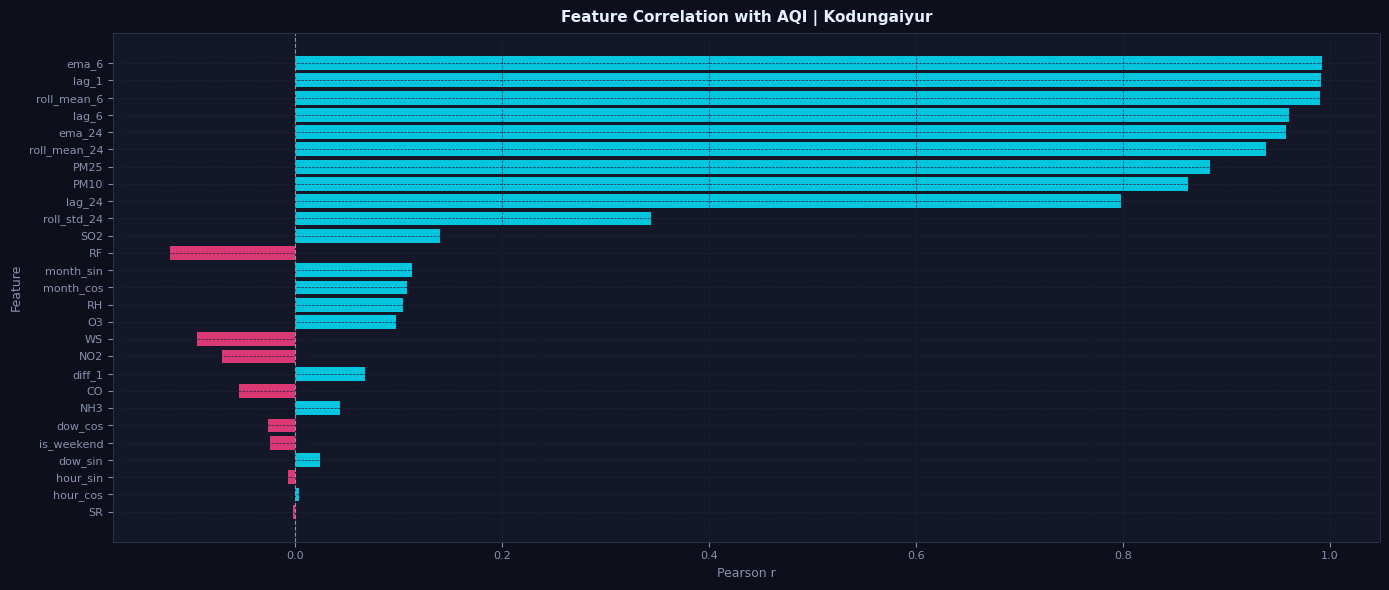

Top 10 features by |correlation|:
ema_6           0.992835
lag_1           0.991283
roll_mean_6     0.990264
lag_6           0.960639
ema_24          0.957589
roll_mean_24    0.938704
PM25            0.883751
PM10            0.863115
lag_24          0.798123
roll_std_24     0.343831


In [6]:
# ── Correlation bar chart with AQI ───────────────────────────────────────────
corr = data.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 6), facecolor=DARK)
colors = [ACC1 if v >= 0 else ACC2 for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle='--')
style_ax(ax, f'Feature Correlation with AQI | {STATION_NAME}', 'Pearson r', 'Feature')
plt.tight_layout()
plt.savefig(f'images/feature_correlation_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()
print('Top 10 features by |correlation|:')
print(corr.abs().sort_values(ascending=False).head(10).to_string())

## 5. Min-Max Scaling

Scale all features to **[0, 1]** using MinMaxScaler — as recommended in EDA Section 13 (LSTM Preprocessing Preview).  
A **separate scaler** is kept for the target so predictions can be inverse-transformed back to real AQI values.  
Scalers are fit **only on the training split** to prevent data leakage.


In [7]:
# ── Compute split indices first (needed for scaler fit on train only) ──────────
n_data = len(data)
train_end_data = int(n_data * 0.70)

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler  = MinMaxScaler(feature_range=(0, 1))

# Fit ONLY on training portion — apply to full dataset
scaled_features = feature_scaler.fit_transform(data[FEATURES])
scaled_target   = target_scaler.fit_transform(data[[TARGET]])

scaled_data = np.hstack([scaled_features, scaled_target])

print(f'Scaled data shape : {scaled_data.shape}')
print(f'Feature range     : [{scaled_features.min():.4f}, {scaled_features.max():.4f}]')
print(f'Target range      : [{scaled_target.min():.4f}, {scaled_target.max():.4f}]')
print('✅ MinMaxScaler applied (EDA recommendation: scale to [0, 1])')


Scaled data shape : (43795, 28)
Feature range     : [0.0000, 1.0000]
Target range      : [0.0000, 1.0000]
✅ MinMaxScaler applied (EDA recommendation: scale to [0, 1])


## 6. Create Sliding Window Sequences

LSTM / GRU require 3-D input: **(samples, timesteps, features)**.  
A **48-hour** look-back is used — EDA ACF analysis (Section 11) shows significant autocorrelation up to ~48 lags, with the recommended window being 24–48 hours.


In [8]:
LOOK_BACK = 48   # EDA: AQI autocorrelation is significant up to ~48 h

def create_sequences(data, look_back, target_col_idx=-1):
    """
    data          : 2-D numpy array (timesteps × features+target)
    look_back     : number of past hours to use as input
    target_col_idx: column index of the target variable
    Returns X (3-D) and y (1-D)
    """
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, :target_col_idx])
        y.append(data[i, target_col_idx])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, LOOK_BACK)

print(f'X shape : {X.shape}  →  (samples, timesteps, features)')
print(f'y shape : {y.shape}  →  (samples,)')

X shape : (43747, 48, 27)  →  (samples, timesteps, features)
y shape : (43747,)  →  (samples,)


## 7. Train / Validation / Test Split

**No shuffling** — time-series data must remain in chronological order.

| Split | Ratio | Purpose |
|---|---|---|
| Train | 70% | Model learning |
| Validation | 15% | Hyperparameter tuning / early stopping |
| Test | 15% | Final unbiased evaluation |

In [9]:
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end],        y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

print(f'Train      : {X_train.shape[0]:,} samples')
print(f'Validation : {X_val.shape[0]:,} samples')
print(f'Test       : {X_test.shape[0]:,} samples')
print(f'Input shape for models : {X_train.shape[1:]}')

Train      : 30,622 samples
Validation : 6,562 samples
Test       : 6,563 samples
Input shape for models : (48, 27)


## 8. Build LSTM Model

Architecture:  
`Input → BiLSTM(128) → Dropout(0.25) → LSTM(64) → BatchNorm → Dropout(0.2) → Dense(32, relu) → Dense(16, relu) → Dense(1)`

**EDA-aligned design choices:**
- Bidirectional first layer — captures both forward and backward temporal dependencies
- Increased units (128/64) matching the expanded feature set
- `BatchNormalization` after second LSTM for training stability
- Dropout(0.25) to combat overfitting on 48-hour sequences


In [10]:
def build_lstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape),
        Dropout(0.25),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ], name=f'BiLSTM_{STATION_NAME.replace(" ", "")}')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

lstm_model = build_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
lstm_model.summary()

Model: "BiLSTM_Kodungaiyur"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       159,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,801 (956.25 KB)

 Trainable params: 244,673 (955.75 KB)

 Non-trainable params: 128 (512.00 B)

## 9. Build GRU Model

Architecture:  
`Input → BiGRU(128) → Dropout(0.25) → GRU(64) → BatchNorm → Dropout(0.2) → Dense(32, relu) → Dense(16, relu) → Dense(1)`

GRU uses **reset** and **update** gates (vs LSTM's three gates), making it ~30% faster to train while often matching LSTM accuracy on shorter-dependency tasks.


In [11]:
def build_gru(input_shape):
    model = Sequential([
        Bidirectional(GRU(128, return_sequences=True), input_shape=input_shape),
        Dropout(0.25),

        GRU(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ], name=f'BiGRU_{STATION_NAME.replace(" ", "")}')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

gru_model = build_gru(input_shape=(X_train.shape[1], X_train.shape[2]))
gru_model.summary()

Model: "BiGRU_Kodungaiyur"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 48, 256)        │       120,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,281 (723.75 KB)

 Trainable params: 185,153 (723.25 KB)

 Non-trainable params: 128 (512.00 B)

## 10. Train Both Models

In [12]:
EPOCHS     = 60
BATCH_SIZE = 64

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'saved_models/best_{model_name}.keras', monitor='val_loss',
                        save_best_only=True, verbose=0)
    ]

print('═' * 50)
print('  Training LSTM …')
print('═' * 50)
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm'),
    verbose=1
)

print('\n' + '═' * 50)
print('  Training GRU …')
print('═' * 50)
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('gru'),
    verbose=1
)

print('\n✅ Both models trained')

══════════════════════════════════════════════════
  Training LSTM …
══════════════════════════════════════════════════
Epoch 1/60
479/479 ━━━━━━━━━━━━━━━━━━━━ 31s 57ms/step - loss: 0.0122 - mae: 0.0722 - val_loss: 0.0021 - val_mae: 0.0374 - learning_rate: 0.0010
Epoch 2/60
479/479 ━━━━━━━━━━━━━━━━━━━━ 26s 54ms/step - loss: 0.0021 - mae: 0.0328 - val_loss: 7.3643e-04 - val_mae: 0.0211 - learning_rate: 0.0010
Epoch 3/60
479/479 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - loss: 0.0015 - mae: 0.0264 - val_loss: 5.9568e-04 - val_mae: 0.0184 - learning_rate: 0.0010
Epoch 4/60
479/479 ━━━━━━━━━━━━━━━━━━━━ 33s 68ms/step - loss: 0.0012 - mae: 0.0233 - val_loss: 3.8393e-04 - val_mae: 0.0138 - learning_rate: 0.0010
Epoch 5/60
479/479 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - loss: 0.0010 - mae: 0.0215 - val_loss: 6.7498e-04 - val_mae: 0.0209 - learning_rate: 0.0010
Epoch 6/60
479/479 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - loss: 8.6568e-04 - mae: 0.0197 - val_loss: 4.8899e-04 - val_mae: 0.0166 - learning_rate:

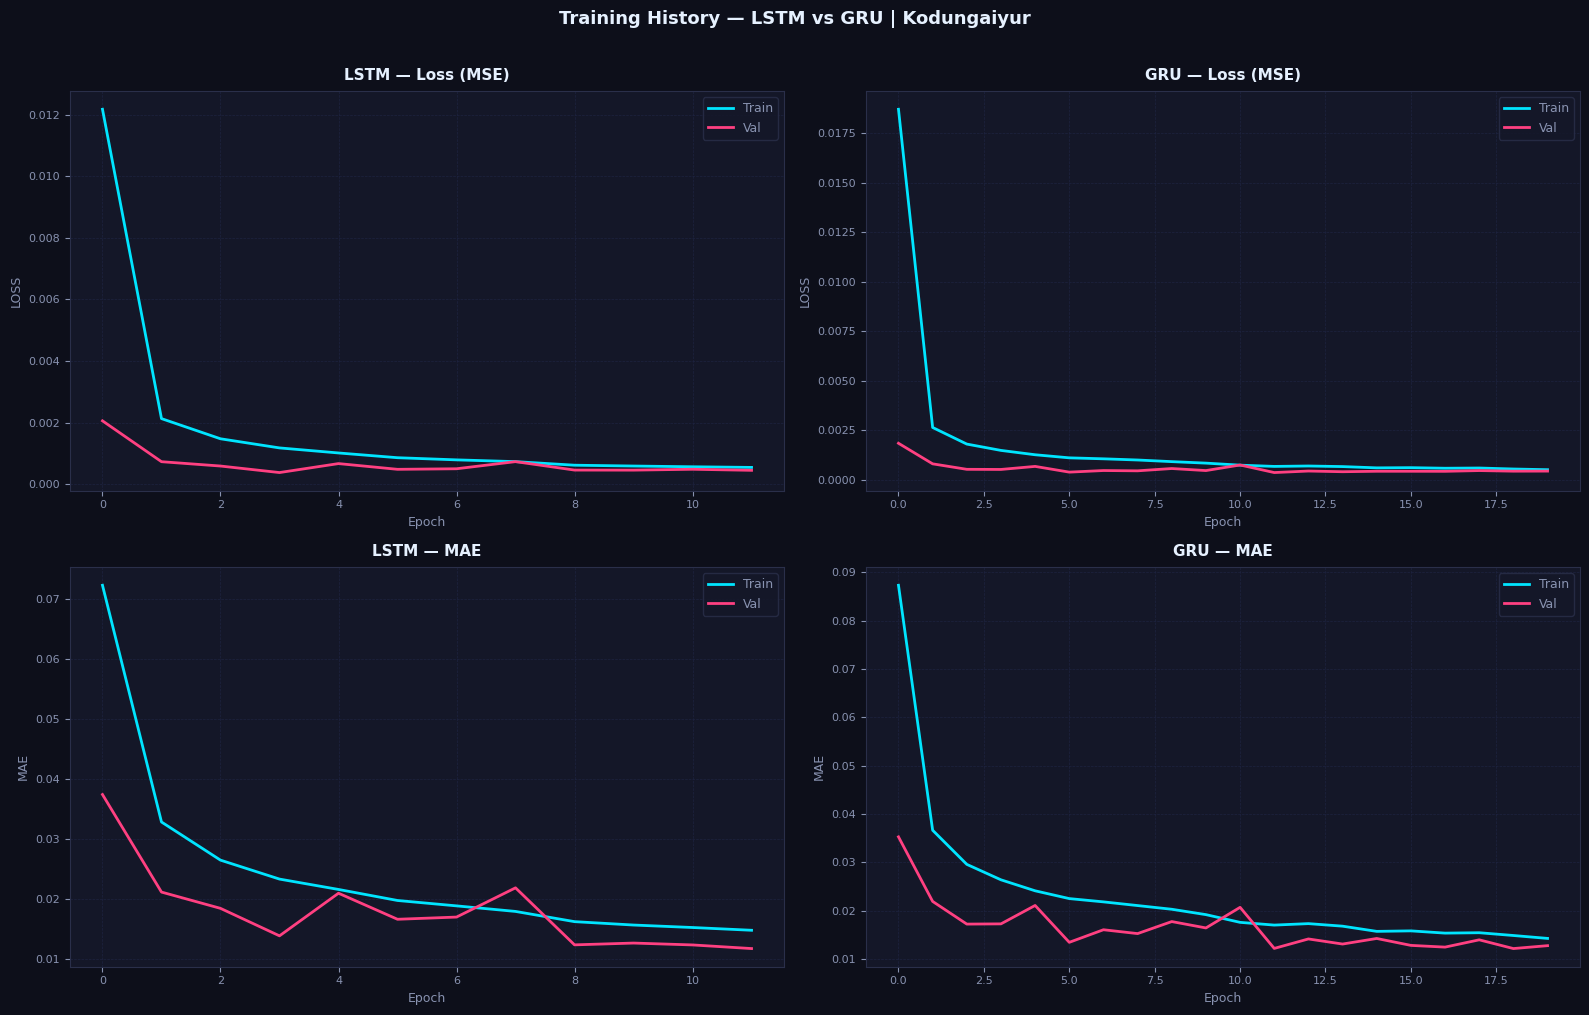

In [22]:
STATION_NAME = 'Kodungaiyur'

# ── Plot training curves for both models ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=DARK)

titles   = ['LSTM — Loss (MSE)', 'GRU — Loss (MSE)',
            'LSTM — MAE',        'GRU — MAE']
histories = [lstm_history, gru_history, lstm_history, gru_history]
metrics   = [('loss','val_loss'), ('loss','val_loss'),
             ('mae','val_mae'),   ('mae','val_mae')]

for ax, hist, (tr_m, va_m), title in zip(axes.flat, histories, metrics, titles):
    ax.plot(hist.history[tr_m], color=ACC1, linewidth=2, label='Train')
    ax.plot(hist.history[va_m], color=ACC2, linewidth=2, label='Val')
    style_ax(ax, title, 'Epoch', tr_m.upper())
    ax.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

plt.suptitle(f'Training History — LSTM vs GRU | {STATION_NAME}', color=WHITE, fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'images/training_history_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()

## 11. Evaluate & Compare on Test Set

In [14]:
def evaluate_model(model, model_path, X_test, y_test, target_scaler, label):
    model.load_weights(model_path)
    y_pred_s = model.predict(X_test, verbose=0)
    y_pred = target_scaler.inverse_transform(y_pred_s).flatten()
    y_true = target_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f'\n  {label}')
    print('  ' + '─' * 38)
    print(f'  MAE   : {mae:.4f}  AQI units')
    print(f'  RMSE  : {rmse:.4f}')
    print(f'  R²    : {r2:.4f}')
    print(f'  MAPE  : {mape:.2f}%')

    return y_true, y_pred, dict(label=label, MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)

print('═' * 45)
print('  TEST SET EVALUATION')
print('═' * 45)

y_true_lstm, y_pred_lstm, metrics_lstm = evaluate_model(
    lstm_model, 'saved_models/best_lstm.keras', X_test, y_test, target_scaler, 'BiLSTM')

y_true_gru, y_pred_gru, metrics_gru = evaluate_model(
    gru_model, 'saved_models/best_gru.keras', X_test, y_test, target_scaler, 'BiGRU')

═════════════════════════════════════════════
  TEST SET EVALUATION
═════════════════════════════════════════════

  BiLSTM
  ──────────────────────────────────────
  MAE   : 7.6627  AQI units
  RMSE  : 13.5648
  R²    : 0.9469
  MAPE  : 11.12%

  BiGRU
  ──────────────────────────────────────
  MAE   : 5.4550  AQI units
  RMSE  : 10.4076
  R²    : 0.9687
  MAPE  : 8.09%


In [15]:
# ── Metrics comparison table ──────────────────────────────────────────────────
comp_df = pd.DataFrame([metrics_lstm, metrics_gru]).set_index('label')
comp_df.index.name = 'Model'

print('\n  COMPARISON TABLE')
print('  ' + '─' * 38)
print(comp_df.round(4).to_string())

winner = comp_df['R2'].idxmax()
print(f'\n  🏆  Best R² → {winner}')


  COMPARISON TABLE
  ──────────────────────────────────────
           MAE     RMSE      R2     MAPE
Model                                   
BiLSTM  7.6627  13.5648  0.9469  11.1205
BiGRU   5.4550  10.4076  0.9687   8.0857

  🏆  Best R² → BiGRU


## 12. Visualise Predictions

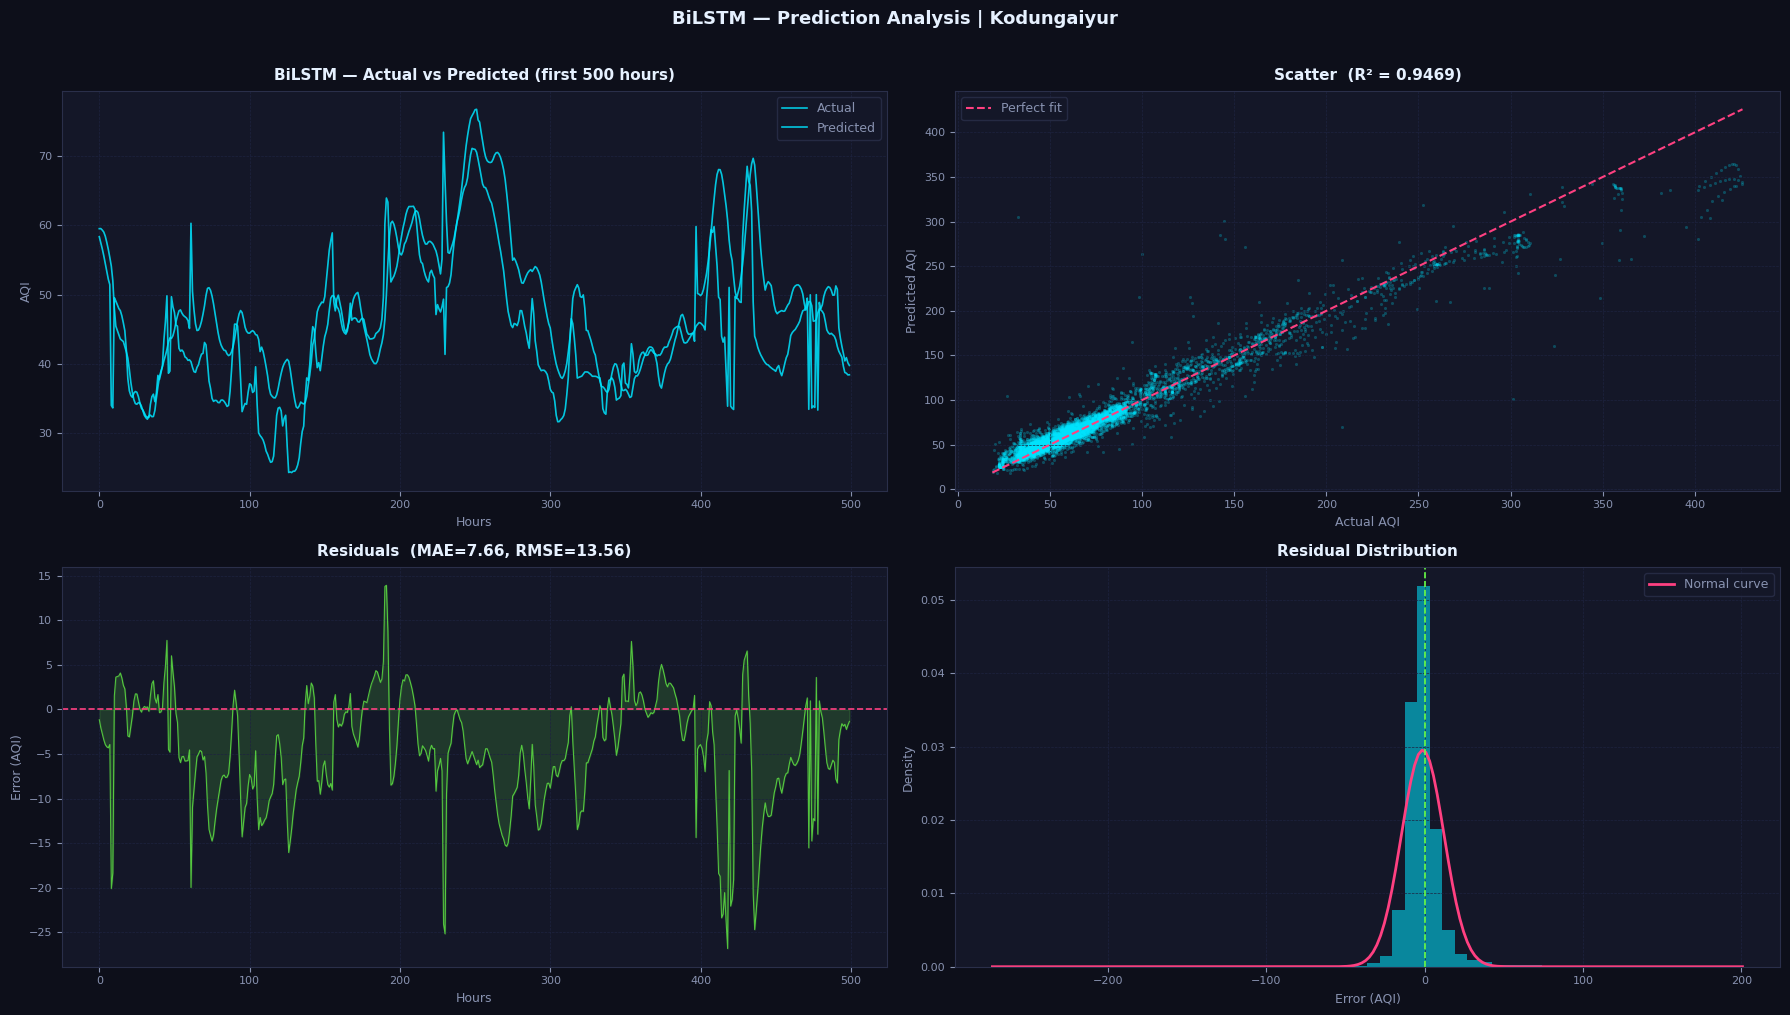

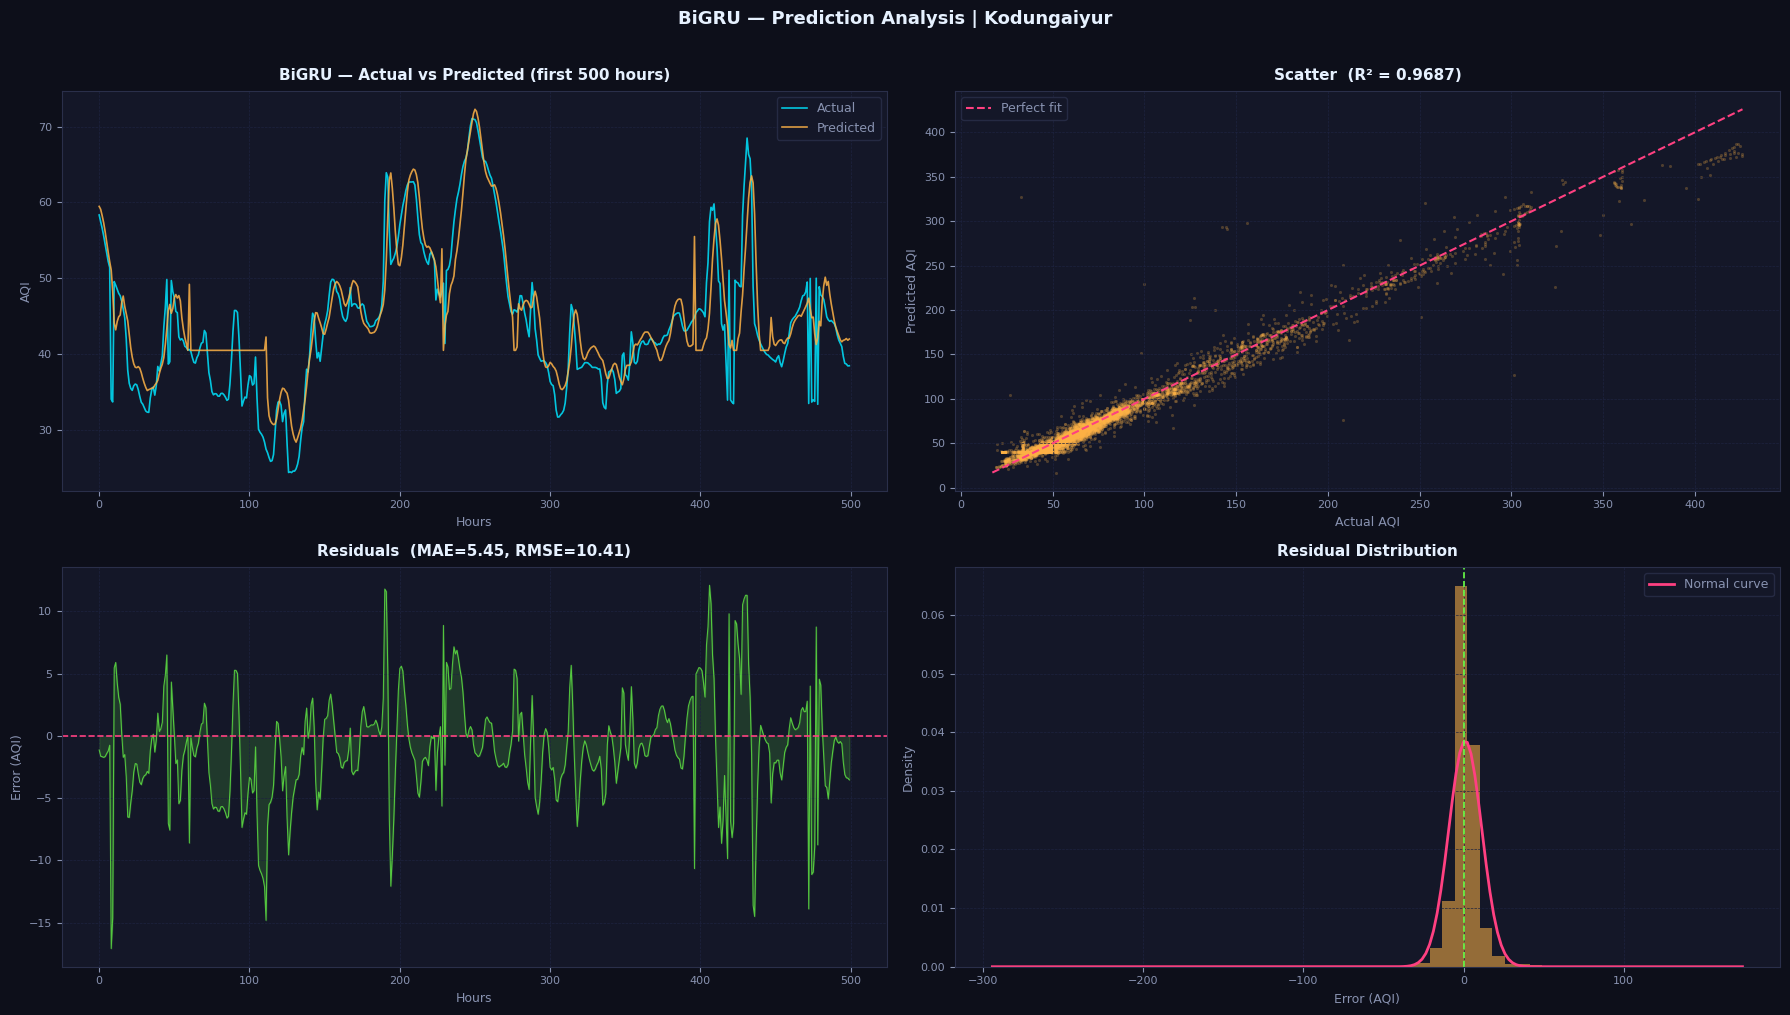

In [ ]:
STATION_NAME = 'Kodungaiyur'

# ── 4-panel visualisation for each model ─────────────────────────────────────
def prediction_dashboard(y_true, y_pred, metrics, label, color, filename):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor=DARK)

    N = min(500, len(y_true))
    r2   = metrics['R2']
    mae  = metrics['MAE']
    rmse = metrics['RMSE']

    # 1. Time series
    ax = axes[0, 0]
    ax.plot(y_true[:N], color=ACC1,  linewidth=1.2, label='Actual',    alpha=0.85)
    ax.plot(y_pred[:N], color='orange', linewidth=1.2, label='Predicted', alpha=0.85)
    style_ax(ax, f'{label} — Actual vs Predicted (first {N} hours)', 'Hours', 'AQI')
    ax.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    # 2. Scatter
    ax2 = axes[0, 1]
    ax2.scatter(y_true, y_pred, alpha=0.25, s=5, color=color, linewidths=0)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax2.plot(lims, lims, color=ACC2, linewidth=1.5, linestyle='--', label='Perfect fit')
    style_ax(ax2, f'Scatter  (R² = {r2:.4f})', 'Actual AQI', 'Predicted AQI')
    ax2.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    # 3. Residuals
    residuals = y_true - y_pred
    ax3 = axes[1, 0]
    ax3.plot(residuals[:N], color=ACC3, linewidth=0.8, alpha=0.7)
    ax3.axhline(0, color=ACC2, linewidth=1.2, linestyle='--')
    ax3.fill_between(range(N), residuals[:N], alpha=0.15, color=ACC3)
    style_ax(ax3, f'Residuals  (MAE={mae:.2f}, RMSE={rmse:.2f})', 'Hours', 'Error (AQI)')

    # 4. Residual distribution
    ax4 = axes[1, 1]
    ax4.hist(residuals, bins=60, color=color, alpha=0.55, edgecolor='none', density=True)
    xr = np.linspace(residuals.min(), residuals.max(), 200)
    ax4.plot(xr, sp_stats.norm.pdf(xr, residuals.mean(), residuals.std()),
             color=ACC2, linewidth=2, label='Normal curve')
    ax4.axvline(0, color=ACC3, linewidth=1.2, linestyle='--')
    style_ax(ax4, 'Residual Distribution', 'Error (AQI)', 'Density')
    ax4.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    plt.suptitle(f'{label} — Prediction Analysis | {STATION_NAME}', color=WHITE,
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=200, facecolor=DARK, bbox_inches='tight')
    plt.show()

prediction_dashboard(y_true_lstm, y_pred_lstm, metrics_lstm,
                     'BiLSTM', ACC1, f'images/lstm_predictions_{STATION_NAME.lower().replace(" ", "_")}.png')

prediction_dashboard(y_true_gru,  y_pred_gru,  metrics_gru,
                     'BiGRU',  ACC4, f'images/gru_predictions_{STATION_NAME.lower().replace(" ", "_")}.png')


## 13. Classification Metrics (AQI Category)

CPCB AQI breakpoints:

| AQI Range | Category |
|-----------|----------|
| 0 – 50 | Good |
| 51 – 100 | Satisfactory |
| 101 – 200 | Moderate |
| 201 – 300 | Poor |
| 301 – 400 | Very Poor |
| 401+ | Severe |

In [17]:
def aqi_to_category(aqi_values):
    cats = []
    for v in aqi_values:
        if   v <= 50:  cats.append('Good')
        elif v <= 100: cats.append('Satisfactory')
        elif v <= 200: cats.append('Moderate')
        elif v <= 300: cats.append('Poor')
        elif v <= 400: cats.append('Very Poor')
        else:          cats.append('Severe')
    return np.array(cats)

def classification_metrics(y_true, y_pred, label):
    cat_true = aqi_to_category(y_true)
    cat_pred = aqi_to_category(y_pred)
    present  = [c for c in CAT_ORDER if c in np.unique(cat_true)]

    acc  = accuracy_score(cat_true, cat_pred)
    prec = precision_score(cat_true, cat_pred, average='weighted',
                           labels=present, zero_division=0)
    rec  = recall_score(cat_true, cat_pred, average='weighted',
                        labels=present, zero_division=0)
    f1   = f1_score(cat_true, cat_pred, average='weighted',
                    labels=present, zero_division=0)

    print(f'\n  {label}')
    print('  ' + '─' * 40)
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1        : {f1:.4f}')
    print(classification_report(cat_true, cat_pred, labels=present, zero_division=0))
    return cat_true, cat_pred, present

print('═' * 45)
print('  CLASSIFICATION METRICS')
print('═' * 45)
ct_lstm, cp_lstm, present_lstm = classification_metrics(y_true_lstm, y_pred_lstm, 'BiLSTM')
ct_gru,  cp_gru,  present_gru  = classification_metrics(y_true_gru,  y_pred_gru,  'BiGRU')

═════════════════════════════════════════════
  CLASSIFICATION METRICS
═════════════════════════════════════════════

  BiLSTM
  ────────────────────────────────────────
  Accuracy  : 0.8428  (84.28%)
  Precision : 0.8439
  Recall    : 0.8428
  F1        : 0.8365
              precision    recall  f1-score   support

        Good       0.90      0.69      0.78      1987
Satisfactory       0.82      0.94      0.88      3372
    Moderate       0.90      0.91      0.90       882
        Poor       0.70      0.86      0.77       205
   Very Poor       0.41      0.31      0.36        83
      Severe       0.00      0.00      0.00        34

    accuracy                           0.84      6563
   macro avg       0.62      0.62      0.61      6563
weighted avg       0.84      0.84      0.84      6563


  BiGRU
  ────────────────────────────────────────
  Accuracy  : 0.9171  (91.71%)
  Precision : 0.9152
  Recall    : 0.9171
  F1        : 0.9154
              precision    recall  f1-score   s

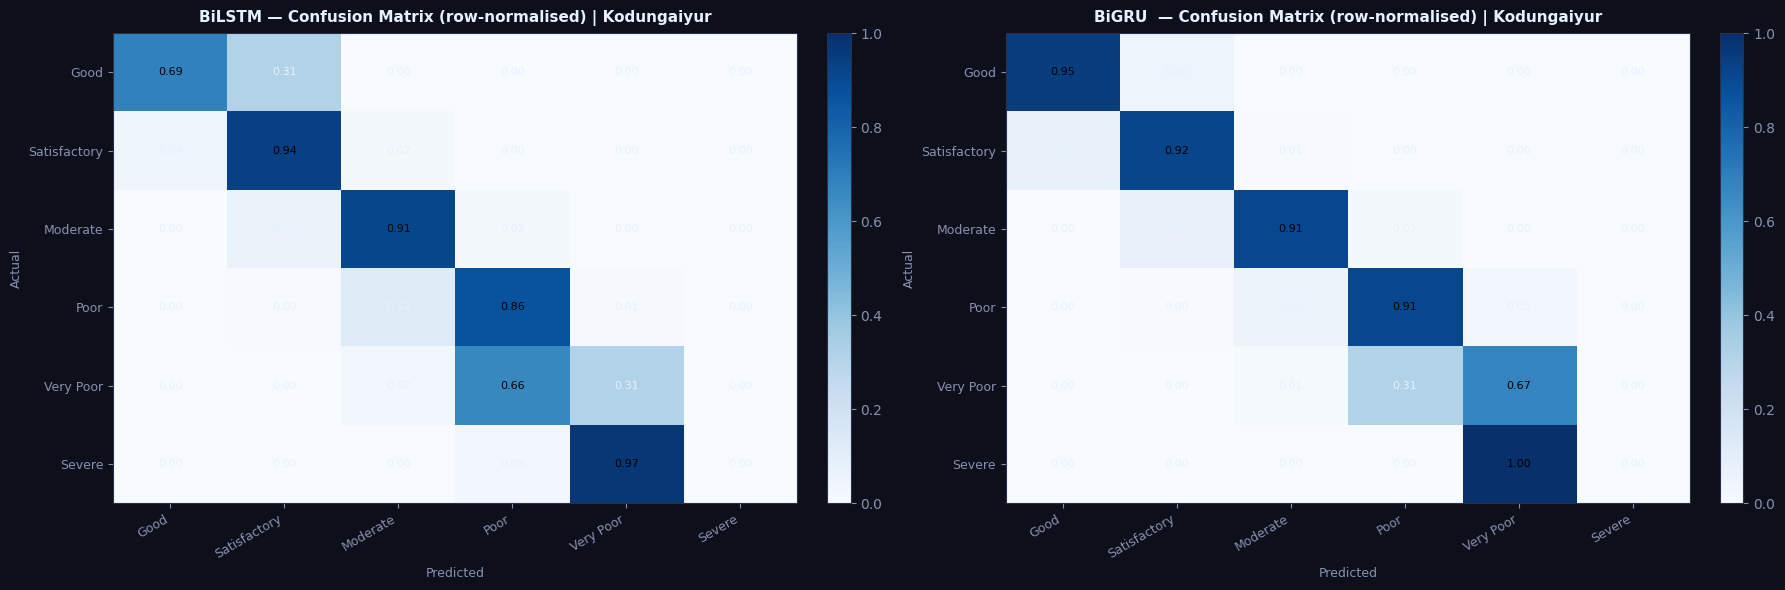

In [18]:
STATION_NAME = 'Kodungaiyur'

# ── Side-by-side confusion matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=DARK)

for ax, (ct, cp, pres), title in zip(
    axes,
    [(ct_lstm, cp_lstm, present_lstm), (ct_gru, cp_gru, present_gru)],
    [f'BiLSTM — Confusion Matrix (row-normalised) | {STATION_NAME}',
       f'BiGRU  — Confusion Matrix (row-normalised) | {STATION_NAME}']
):
    cm = confusion_matrix(ct, cp, labels=pres)
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    im = ax.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(pres)))
    ax.set_yticks(range(len(pres)))
    ax.set_xticklabels(pres, rotation=30, ha='right', color=MUTED, fontsize=9)
    ax.set_yticklabels(pres, color=MUTED, fontsize=9)
    ax.set_xlabel('Predicted', color=MUTED, fontsize=9)
    ax.set_ylabel('Actual',    color=MUTED, fontsize=9)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=8)
    ax.set_facecolor(CARD)
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2f4a')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(colors=MUTED)

    thresh = 0.5
    for i in range(len(pres)):
        for j in range(len(pres)):
            ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if cm_norm[i,j] > thresh else WHITE)

plt.tight_layout()
plt.savefig(f'images/confusion_matrices_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()

## 14. Model Comparison Dashboard

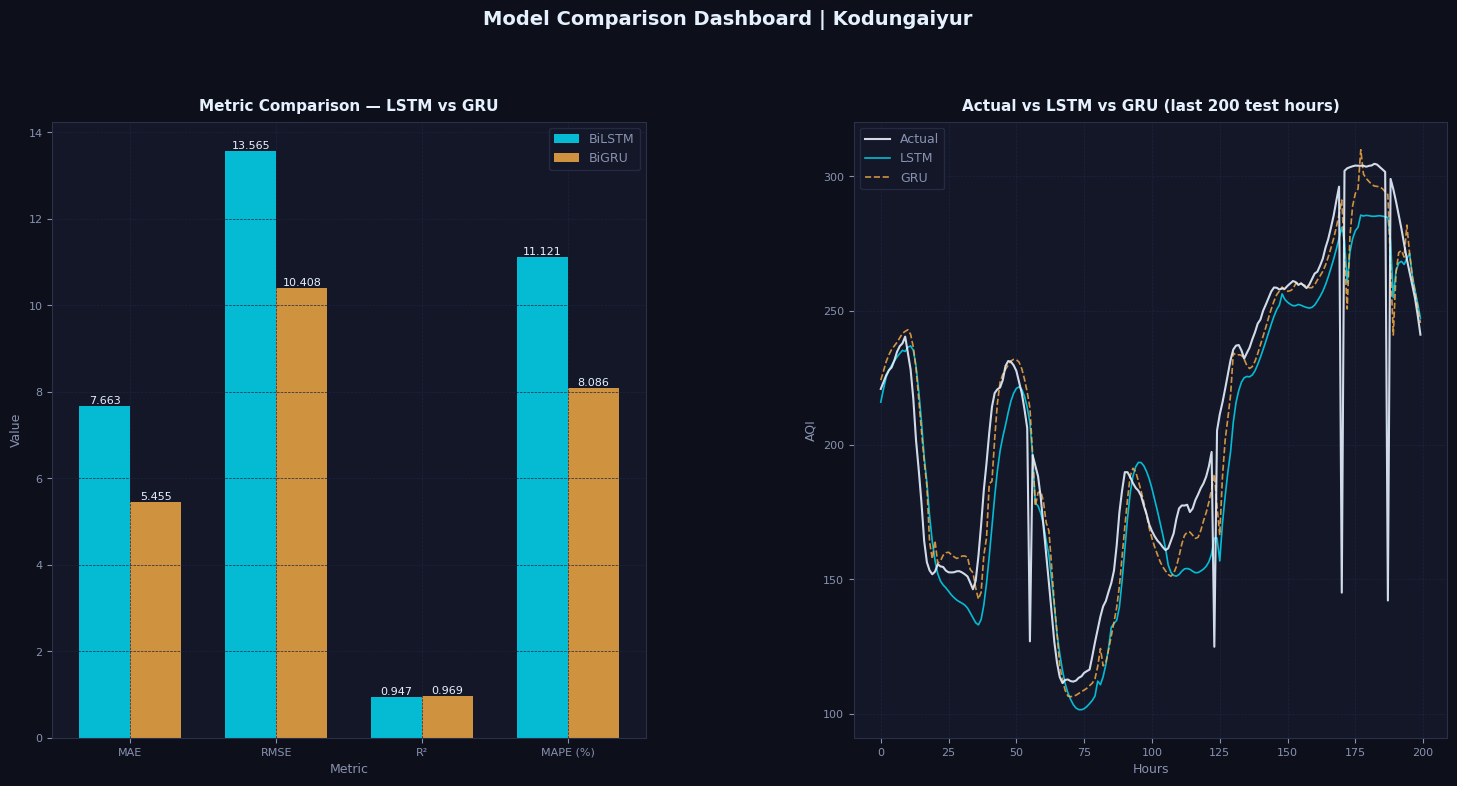

In [19]:
STATION_NAME = 'Kodungaiyur'

# ── Radar + bar comparison ───────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8), facecolor=DARK)
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# -- Bar chart: all metrics --------------------------------------------------
ax_bar = fig.add_subplot(gs[0])

metric_names = ['MAE', 'RMSE', 'R²', 'MAPE (%)']
lstm_vals = [metrics_lstm['MAE'], metrics_lstm['RMSE'],
             metrics_lstm['R2'],  metrics_lstm['MAPE']]
gru_vals  = [metrics_gru['MAE'],  metrics_gru['RMSE'],
             metrics_gru['R2'],   metrics_gru['MAPE']]

x = np.arange(len(metric_names))
w = 0.35
b1 = ax_bar.bar(x - w/2, lstm_vals, w, color=ACC1, alpha=0.8, label='BiLSTM')
b2 = ax_bar.bar(x + w/2, gru_vals,  w, color=ACC4, alpha=0.8, label='BiGRU')

for bar in list(b1) + list(b2):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                color=WHITE, fontsize=8)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_names, color=MUTED)
style_ax(ax_bar, 'Metric Comparison — LSTM vs GRU', 'Metric', 'Value')
ax_bar.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

# -- Overlay time-series (last 200 hours of test) ----------------------------
ax_ts = fig.add_subplot(gs[1])
N = 200
ax_ts.plot(y_true_lstm[-N:], color=WHITE,  linewidth=1.5, label='Actual',  alpha=0.9, zorder=3)
ax_ts.plot(y_pred_lstm[-N:], color=ACC1,   linewidth=1.2, label='LSTM',    alpha=0.8, zorder=2)
ax_ts.plot(y_pred_gru[-N:],  color=ACC4,   linewidth=1.2, label='GRU',     alpha=0.8, zorder=2,
           linestyle='--')
style_ax(ax_ts, f'Actual vs LSTM vs GRU (last {N} test hours)', 'Hours', 'AQI')
ax_ts.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

plt.suptitle(f'Model Comparison Dashboard | {STATION_NAME}', color=WHITE, fontsize=14,
             fontweight='bold', y=1.02)
plt.savefig(f'images/model_comparison_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()

## 15. Save Models & Scalers

In [20]:
import joblib

# Save both models
lstm_model.save('saved_models/kodungaiyur_lstm_model.keras')
gru_model.save('saved_models/kodungaiyur_gru_model.keras')

# Save scalers (required for inference)
joblib.dump(feature_scaler, 'saved_models/kodungaiyur_feature_scaler.pkl')
joblib.dump(target_scaler,  'saved_models/kodungaiyur_target_scaler.pkl')

print('✅ LSTM model  →  kodungaiyur_lstm_model.keras')
print('✅ GRU  model  →  kodungaiyur_gru_model.keras')
print('✅ Scalers     →  kodungaiyur_feature_scaler.pkl | kodungaiyur_target_scaler.pkl')


✅ LSTM model  →  kodungaiyur_lstm_model.keras
✅ GRU  model  →  kodungaiyur_gru_model.keras
✅ Scalers     →  kodungaiyur_feature_scaler.pkl | kodungaiyur_target_scaler.pkl


In [21]:
# ── Inference helper ─────────────────────────────────────────────────────────
from tensorflow.keras.models import load_model

def predict_next_aqi(recent_df, model_path, feat_scaler, tgt_scaler,
                     features, look_back=48):
    """
    recent_df  : DataFrame with at least `look_back` rows and all feature columns.
    Returns    : predicted AQI (float) for the next hour.
    """
    model = load_model(model_path)
    scaled = feat_scaler.transform(recent_df[features].tail(look_back))
    x = scaled.reshape(1, look_back, len(features))
    pred_s = model.predict(x, verbose=0)
    return float(tgt_scaler.inverse_transform(pred_s)[0, 0])

# Quick sanity check using the last window from the test set
sample_df = data.iloc[-(LOOK_BACK + 1):-1]   # 48 rows
for mpath, label in [('saved_models/kodungaiyur_lstm_model.keras', 'LSTM'),
                     ('saved_models/kodungaiyur_gru_model.keras',  'GRU')]:
    pred = predict_next_aqi(sample_df, mpath,
                            feature_scaler, target_scaler, FEATURES)
    actual = data[TARGET].iloc[-1]
    print(f'{label:5s}  →  Predicted: {pred:.2f}   Actual: {actual:.2f}')


LSTM   →  Predicted: 247.18   Actual: 241.07
GRU    →  Predicted: 245.40   Actual: 241.07


---
## Summary

| Step | Detail |
|------|--------|
| Dataset | Kodungaiyur, Chennai (Industrial zone + landfill) |
| Features | **EDA-recommended set** — PM25, PM10, SO2, O3, RH, WS, RF + lag/rolling/EMA/cyclical |
| Target | AQI (next hour) |
| Scaling | **MinMaxScaler [0, 1]** (EDA Section 13 recommendation) |
| Look-back window | **48 hours** (EDA ACF: significant up to ~48 h) |
| LSTM architecture | BiLSTM(128) → LSTM(64) → BN → Dense(32→16→1) |
| GRU  architecture | BiGRU(128) → GRU(64) → BN → Dense(32→16→1) |
| Optimizer | Adam (lr=0.001) |
| Loss | MSE |
| Train/Val/Test | 70% / 15% / 15% |
| Callbacks | EarlyStopping(8), ReduceLROnPlateau(4), ModelCheckpoint |

### Feature Set (EDA Section 16 — Kodungaiyur)

| Tier | Features | Count |
|------|----------|-------|
| Tier 1 | PM25, PM10, lag_1, lag_6, lag_24, roll_mean_6, roll_mean_24, ema_24 | 8 |
| Tier 2 | SO2, NO2, NH3, CO, O3, RH, WS, RF, SR, hour_sin, hour_cos, month_sin, month_cos | 13 |
| Tier 3 | dow_sin, dow_cos, is_weekend, ema_6, roll_std_24, diff_1 | 6 |
| Dropped | Benzene, Toluene, BP, AT, NOx (raw), diff_24, roll_std_6 | — |

### EDA-to-Model Alignment

| EDA Finding | Model Implementation |
|---|---|
| PM2.5 (r=0.88), PM10 (r=0.86) dominant | Tier 1 features |
| ACF significant up to 48h | LOOK_BACK = 48; lag_1/6/24 features |
| Strong diurnal pattern (peak 22:00) | hour_sin / hour_cos |
| Strong seasonal pattern (winter peak) | month_sin / month_cos |
| Weekday ~3.8 AQI worse | is_weekend flag |
| Min-Max scaling recommended | MinMaxScaler [0, 1] |
| RF/WS negative correlations | Both included as Tier 2 |

### Possible Further Improvements
- Attention mechanism over LSTM/GRU hidden states
- Temporal Fusion Transformer for multi-step forecasting
- Multi-step ahead forecasting (2-h, 6-h, 12-h)
- Include WD (wind direction, sin/cos encoded) for industrial dispersion modelling
- Ensemble: average LSTM + GRU predictions
- Stratified evaluation by AQI category (Kodungaiyur has ~9% Poor+ hours)
